# US 13

In [15]:
## Importar Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import scipy

In [16]:
# Load declaration-level data so each declaration is counted once.
declarations_df = pd.read_csv("../Dados/dataset1_declarations.csv")

In [17]:
# Prepare declaration-level data and shared summaries.
declarations_df = pd.read_csv("../Dados/dataset1_declarations.csv")

analysis_df = declarations_df.drop_duplicates(subset="declaration_id").copy()

print(f"Total rows loaded: {len(declarations_df)}")
print(f"Unique declarations after deduplication: {len(analysis_df)}")
print()

# Summary tables
declaration_type_counts = analysis_df["declaration_type"].value_counts().sort_index()
declaration_type_share = (declaration_type_counts / declaration_type_counts.sum() * 100).round(2)
role_counts = analysis_df["role"].value_counts().sort_values(ascending=False)
institution_counts = analysis_df["institution"].value_counts().sort_values(ascending=False)

print("Declaration type distribution (%):")
print(pd.DataFrame({"count": declaration_type_counts, "share_%": declaration_type_share}))
print()

print("Declarations by role:")
print(role_counts)
print()

print("Declarations by institution:")
print(institution_counts)
print()

# Shared theme for all charts
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f9fa",
    }
)


Total rows loaded: 13395
Unique declarations after deduplication: 13395

Declaration type distribution (%):
                  count  share_%
declaration_type                
exceptional         860     6.42
initial            2364    17.65
regular           10171    75.93

Declarations by role:
role
Judge              8912
MP                 2360
Advisor            1572
State Secretary     376
Minister            175
Name: count, dtype: int64

Declarations by institution:
institution
Courts        8912
Parliament    2360
Government    2123
Name: count, dtype: int64



### Graph 1: Declaration Type Proportion

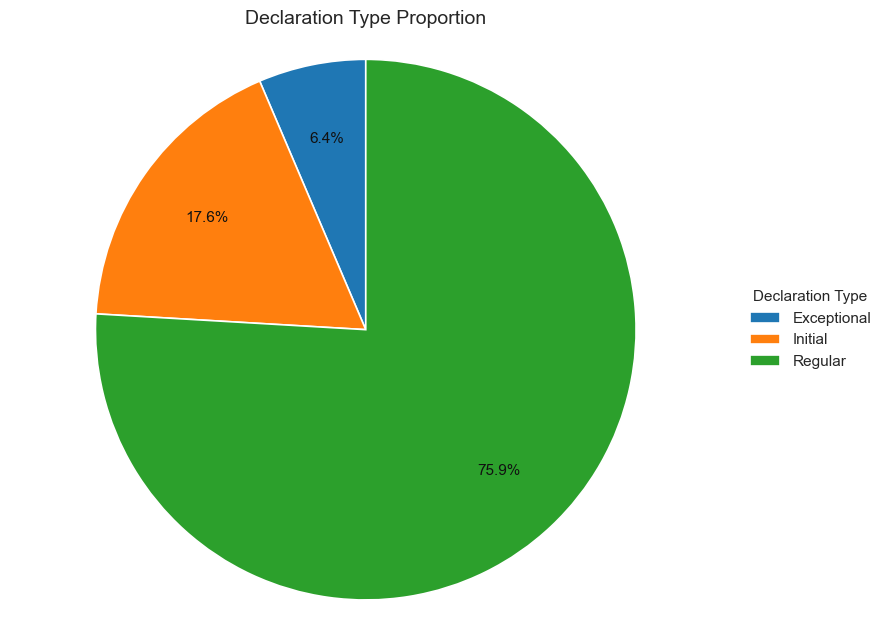

In [23]:
fig, ax = plt.subplots(figsize=(9, 6.5))

type_labels = [label.replace("_", " ").title() for label in declaration_type_counts.index]

wedges, _, autotexts = ax.pie(
    declaration_type_counts,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.72,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)

for autotext in autotexts:
    autotext.set_color("#111111")
    autotext.set_fontsize(11)

ax.legend(
    wedges,
    type_labels,
    title="Declaration Type",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

ax.set_title("Declaration Type Proportion")
ax.axis("equal")
plt.tight_layout()
plt.show()

### Graph 2: Total Declarations by Role

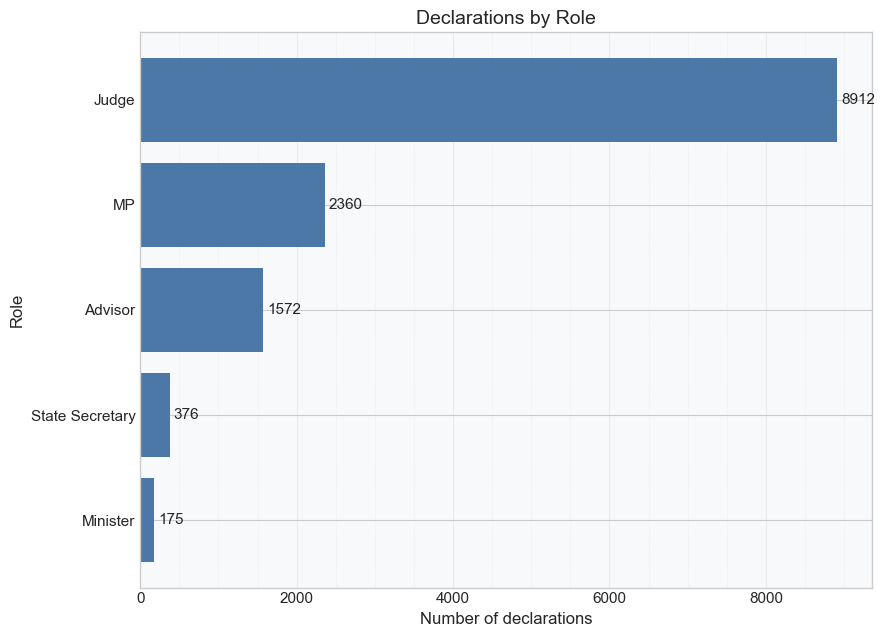

In [19]:
fig, ax = plt.subplots(figsize=(9, 6.5))

role_counts_plot = role_counts.sort_values(ascending=True)
role_bars = ax.barh(role_counts_plot.index, role_counts_plot.values, color="#4C78A8")

ax.set_title("Declarations by Role")
ax.set_xlabel("Number of declarations")
ax.set_ylabel("Role")
ax.set_axisbelow(True)
ax.minorticks_on()
ax.grid(axis="x", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
ax.grid(axis="x", which="minor", linestyle=":", linewidth=0.7, alpha=0.30)
ax.bar_label(role_bars, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

### Graph 3: Total Declarations by Institution

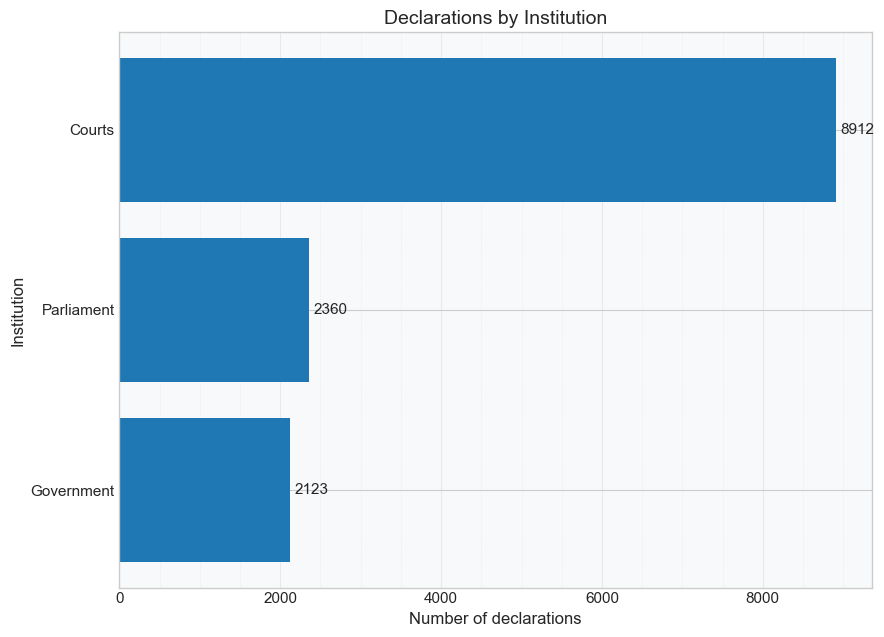

In [24]:
fig, ax = plt.subplots(figsize=(9, 6.5))

institution_counts_plot = institution_counts.sort_values(ascending=True)
institution_bars = ax.barh(
    institution_counts_plot.index,
    institution_counts_plot.values,
)

ax.set_title("Declarations by Institution")
ax.set_xlabel("Number of declarations")
ax.set_ylabel("Institution")
ax.set_axisbelow(True)
ax.minorticks_on()
ax.grid(axis="x", which="major", linestyle="-", linewidth=0.8, alpha=0.35)
ax.grid(axis="x", which="minor", linestyle=":", linewidth=0.7, alpha=0.30)
ax.bar_label(institution_bars, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

In [21]:
most_common_type = declaration_type_counts.idxmax()
most_common_type_count = int(declaration_type_counts.max())
most_common_role = role_counts.idxmax()
most_common_role_count = int(role_counts.max())
most_common_institution = institution_counts.idxmax()
most_common_institution_count = int(institution_counts.max())

print("Interpretation:")
print(
    f"- The most common declaration type is '{most_common_type}' with {most_common_type_count} declarations "
    f"({declaration_type_share[most_common_type]}% of the total)."
)
print(f"- The role with the most declarations is '{most_common_role}' with {most_common_role_count} declarations.")
print(
    f"- The institution with the most declarations is '{most_common_institution}' "
    f"with {most_common_institution_count} declarations."
)

Interpretation:
- The most common declaration type is 'regular' with 10171 declarations (75.93% of the total).
- The role with the most declarations is 'Judge' with 8912 declarations.
- The institution with the most declarations is 'Courts' with 8912 declarations.
